In [ ]:

import pandas as pd
import numpy as np
import re
import joblib
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:

career_df = pd.read_csv("career_it_recomendation.csv")

career_df.head()

,jenis_kelamin,jurusan_s1,spesialisasi_s1,minat,keterampilan,judul_sertifikasi,pekerjaan_pertama,ipk_s1,profil_lengkap
0,Female,Sarjana Sains,Aplikasi Komputer,Cloud Computing,Java; Python; SQL,"Linux,Git",Software,3.40,Sarjana Sains | Aplikasi Komputer | Cloud Comp...
1,Male,Sarjana Teknik,Teknik Informatika,Teknologi,Berpikir Analitis; Berpikir Kritis; Kerja di B...,Microsoft Certification,Computer Software Engineer,2.66,Sarjana Teknik | Teknik Informatika | Technolo...
2,Female,Sarjana Teknik,Teknik Informatika,Teknologi,C++; HTML; Java,"C,C++,Html,Java",Analis Jaringan,2.93,Sarjana Teknik | Teknik Informatika | Technolo...
3,Male,Sarjana Teknik,Teknik Informatika,Teknologi,Tidak Tersedia,No,Software Engineer Trainee,2.96,Sarjana Teknik | Teknik Informatika | Technolo...
4,Male,Sarjana Teknik,Teknik Informatika,Teknologi,Berpikir Kritis; Java; Linux; Pemrograman; Pyt...,Redhat Certification,Senior Software Engineer,2.77,Sarjana Teknik | Teknik Informatika | Technolo...


In [ ]:

remove_jobs = [
    "Tidak Tersedia",
    "Mahasiswa (Belum Bekerja)"
]

career_df = career_df[
    ~career_df["pekerjaan_pertama"].isin(remove_jobs)
].copy()

career_df = career_df.drop_duplicates().copy()

career_df["pekerjaan_pertama"].value_counts().head(15)

,count
pekerjaan_pertama,
Computer Software Engineer,13
Data Analyst,11
Software Engineer,10
Software Developer,8
Associate Consultant,8
Data Scientist,5
Business Analyst,4
Cyber Security Analyst,4
Insinyur Mekanik,3


In [ ]:

top_jobs = career_df["pekerjaan_pertama"].value_counts().head(10).index

career_df = career_df[
    career_df["pekerjaan_pertama"].isin(top_jobs)
].copy()

career_df["pekerjaan_pertama"].value_counts()

,count
pekerjaan_pertama,
Computer Software Engineer,13
Data Analyst,11
Software Engineer,10
Software Developer,8
Associate Consultant,8
Data Scientist,5
Business Analyst,4
Cyber Security Analyst,4
Web Developer,3


In [ ]:

X = career_df["profil_lengkap"]
y = career_df["pekerjaan_pertama"]

In [ ]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

X_cleaned = X.apply(clean_text)

X_cleaned.head()

,profil_lengkap
1,sarjana teknik teknik informatika technology b...
15,sarjana teknik teknik informatika software job...
30,sarjana teknik teknik informatika data scienti...
36,sarjana teknik aplikasi komputer technology in...
48,sarjana teknik teknik informatika data scienti...


In [ ]:

tfidf = TfidfVectorizer(max_features=1000)

X_tfidf = tfidf.fit_transform(X_cleaned)

X_tfidf.shape

(69, 257)

In [ ]:

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Jumlah class:", len(encoder.classes_))
print(encoder.classes_)

Jumlah class: 10
['Associate Consultant' 'Business Analyst' 'Computer Software Engineer'
 'Cyber Security Analyst' 'Data Analyst' 'Data Scientist'
 'Insinyur Mekanik' 'Software Developer' 'Software Engineer'
 'Web Developer']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (55, 257)
X_test : (14, 257)
y_train: (55,)
y_test : (14,)


In [ ]:

X_train_array = X_train.toarray()
X_test_array = X_test.toarray()

In [ ]:

input_dim = X_train_array.shape[1]
num_classes = len(encoder.classes_)

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [ ]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:

history = model.fit(
    X_train_array,
    y_train,
    validation_data=(X_test_array, y_test),
    epochs=20,
    batch_size=16
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.0545 - loss: 2.3134 - val_accuracy: 0.1429 - val_loss: 2.2745
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.2182 - loss: 2.2757 - val_accuracy: 0.3571 - val_loss: 2.2544
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4364 - loss: 2.2315 - val_accuracy: 0.3571 - val_loss: 2.2342
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5273 - loss: 2.2049 - val_accuracy: 0.3571 - val_loss: 2.2113
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4909 - loss: 2.1736 - val_accuracy: 0.3571 - val_loss: 2.1835
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5273 - loss: 2.1407 - val_accuracy: 0.3571 - val_loss: 2.1520
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5636 - loss: 2.0906 - val_accuracy: 0.3571 - val_loss: 2.1144
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4727 - loss: 2.0406 - val_accuracy: 0.3571 - val_loss: 2.073

In [ ]:

loss, accuracy = model.evaluate(X_test_array, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7143 - loss: 1.3563
Test Loss: 1.3563345670700073
Test Accuracy: 0.7142857313156128


In [ ]:

y_pred_prob = model.predict(X_test_array)
y_pred = np.argmax(y_pred_prob, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [ ]:

print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(encoder.classes_)),
    target_names=encoder.classes_,
    zero_division=0
))

                            precision    recall  f1-score   support

      Associate Consultant       1.00      1.00      1.00         2
          Business Analyst       0.00      0.00      0.00         1
Computer Software Engineer       0.60      1.00      0.75         3
    Cyber Security Analyst       1.00      1.00      1.00         1
              Data Analyst       0.50      1.00      0.67         2
            Data Scientist       0.00      0.00      0.00         1
          Insinyur Mekanik       0.00      0.00      0.00         0
        Software Developer       1.00      1.00      1.00         2
         Software Engineer       0.00      0.00      0.00         2
             Web Developer       0.00      0.00      0.00         0

                  accuracy                           0.71        14
                 macro avg       0.41      0.50      0.44        14
              weighted avg       0.56      0.71      0.61        14



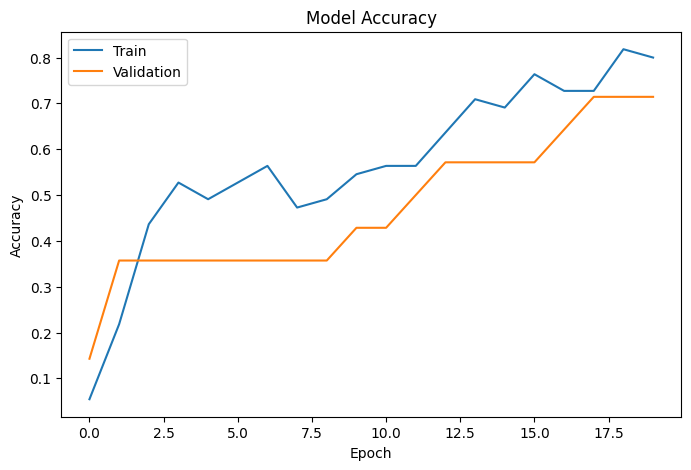

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

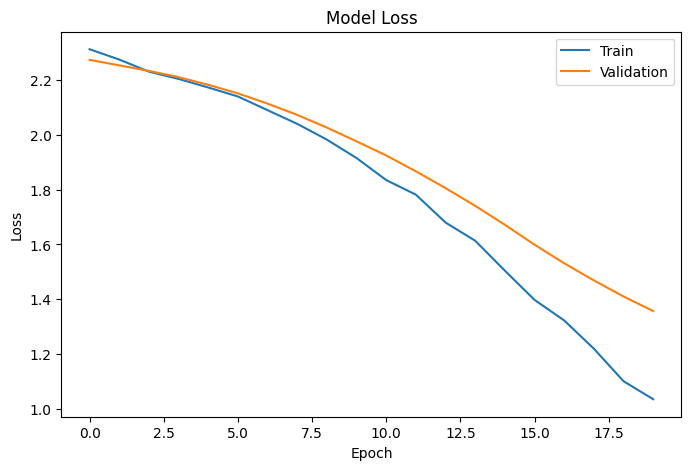

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:

sample_profile = ["saya memiliki keterampilan python sql data analysis machine learning"]

sample_cleaned = [clean_text(sample_profile[0])]
sample_vector = tfidf.transform(sample_cleaned).toarray()

prediction = model.predict(sample_vector)
predicted_label = np.argmax(prediction, axis=1)
predicted_job = encoder.inverse_transform(predicted_label)

print("Predicted Job:", predicted_job[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Predicted Job: Data Analyst


In [ ]:

os.makedirs("models", exist_ok=True)

model.save("models/career_recommendation_model_it.keras")
joblib.dump(tfidf, "models/tfidf_vectorizer_it.pkl")
joblib.dump(encoder, "models/label_encoder_it.pkl")

['models/label_encoder_it.pkl']

## Kesimpulan Baseline Modeling

Model baseline berhasil dibuat menggunakan TensorFlow untuk memprediksi `pekerjaan_pertama` berdasarkan `profil_lengkap` pengguna. Dataset difilter dengan menghapus target tidak valid dan mengambil 10 pekerjaan terbanyak agar proses training lebih stabil. Data teks diproses menggunakan TF-IDF, sedangkan target pekerjaan dikonversi menggunakan LabelEncoder.